Mann-Kendall Test
Reference: https://github.com/mombadi/Ombadi-Risser-2022-_Increasing-Trends-in-Extreme-Volatility-of-Daily-Max-Temperature/blob/main/GHCN.ipynb

In [1]:

import os
import glob 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import pymannkendall as mk
import scipy as sc
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import math
import seaborn as sns
%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

import constants

### functions and file loading

In [106]:
def deseasonize_df(df):
    '''
    df: DataFrame with datetime index and a single column of data
        e.g. columns = ['NAMELSAD', '200101', '200102', ...] or ['NAMELSAD', 'nee_mean_200101', 'nee_mean_200102', ...]

    Returns a DataFrame with the seasonal cycle removed, by subtracting the average of all Januarys from each Januray value (same for Feb, Mar ...etc). 
    '''
    df = df.copy()
    monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
    for month in monthly_avg.columns:
        df.loc[:, df.columns.str.endswith(month)] -= monthly_avg[month].values[:, None]
    return df

def mk_trend_test(df, alpha=0.05, name='NAMELSAD'):
    """
    Perform the Mann-Kendall trend test on each row of the DataFrame.
    
    Parameters:
        df (pd.DataFrame): DataFrame with time series data.
            assuming the first column is the index (e.g., NAMELSAD). the rest are time series values.
        name (str): Name of the first column in the DataFrame ('NAMELSAD' in this case).
        alpha (float): Significance level for the test.
        
    Returns:
        pd.DataFrame: DataFrame with trend test results.
    """
    results = []
    for index, row in df.iterrows():
        msa_data = row.iloc[1:].values.flatten()

        # Perform the Mann-Kendall test
        result = mk.original_test(msa_data, alpha=0.05)
        results.append([row[name], result.p, result.slope, result.trend])
    
    return pd.DataFrame(results, columns=[name, 'p', 'slope', 'trend'], index=df.index)

def print_trend_brief_info(trend_df, c_i, show_msa=False):
    """
    Print the number of increasing and decreasing trends for a given climate index.
    
    Parameters:
        trend_df (pd.DataFrame): DataFrame containing trend results.
        c_i (str): Climate index name (e.g., 'ppt', 'tmean', 'tdmean').
    Output:
        Prints the number of increasing and decreasing trends MSA
    """
    increasing = trend_df[trend_df['trend'] == 'increasing']
    decreasing = trend_df[trend_df['trend'] == 'decreasing']
    
    if increasing.empty:
        print(f'No increasing MSAs found for {c_i}.')
    else:
        print(f"Number of increasing {c_i} MSAs: {len(increasing)}")
        if show_msa:
            print('increasing MSAs:', increasing['NAMELSAD'].values)

    if decreasing.empty:
        print(f'No decreasing MSAs found for {c_i}.')
    else:
        print(f"Number of decreasing {c_i} MSAs: {len(decreasing)}")
        if show_msa:
            print('decreasing MSAs:', decreasing['NAMELSAD'].values)

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_trend_map(msa_shp, trend_df, title="Trend Map"):
    """
    Plots a choropleth map showing slope trends by MSA using a warm-cool color scheme,
    with boundaries of all MSAs shown.

    Parameters:
        msa_shp (GeoDataFrame): Shapefile of MSAs with a 'NAMELSAD' column.
        trend_df (DataFrame): DataFrame calculated from the Mann-Kendall test results. columns ['NAMELSAD', 'p', 'slope', 'trend'].
        title (str): Title of the plot.

    Output: 
    A map showing the MSAs with increasing trends in blue and decreasing trends in red.
    """
    # Merge trend data with shapefile
    msa_merged = msa_shp.merge(trend_df, on='NAMELSAD', how='left')

    # Assign slope value only if trend is increasing or decreasing
    msa_merged['plot_slope'] = msa_merged.apply(
        lambda row: row['slope'] if row['trend'] in ['increasing', 'decreasing'] else None,
        axis=1
    )

    # Define normalization
    slope_values = msa_merged['plot_slope'].dropna()
    if slope_values.empty:
        raise ValueError("No valid slope values to plot.")

    vmin, vmax = slope_values.min(), slope_values.max()
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    
    cmap = plt.cm.RdBu  # Increasing = red, Decreasing = blue

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot all MSA boundaries in light gray
    msa_shp.boundary.plot(ax=ax, linewidth=0.5, color='lightgray')

    # Plot MSAs with trend
    msa_merged.dropna(subset=['plot_slope']).plot(
        column='plot_slope', cmap=cmap, norm=norm,
        linewidth=0.4, edgecolor='black', ax=ax, legend=True
    )

    ax.set_title(f"{title}\n(increasing = blue, decreasing = red, no trend = no color)", fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


In [107]:
msa_shp = gpd.read_file(constants.MSA_FILE)
msa_region_name = pd.read_csv(constants.MSA_NAME_REGION_TABLE)

### Carbon Sequestration Trend

#### Using previous flux 2001-2015 nee product

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\1084722401.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing Carbon sequestration MSAs: 5
Number of decreasing Carbon sequestration MSAs: 100


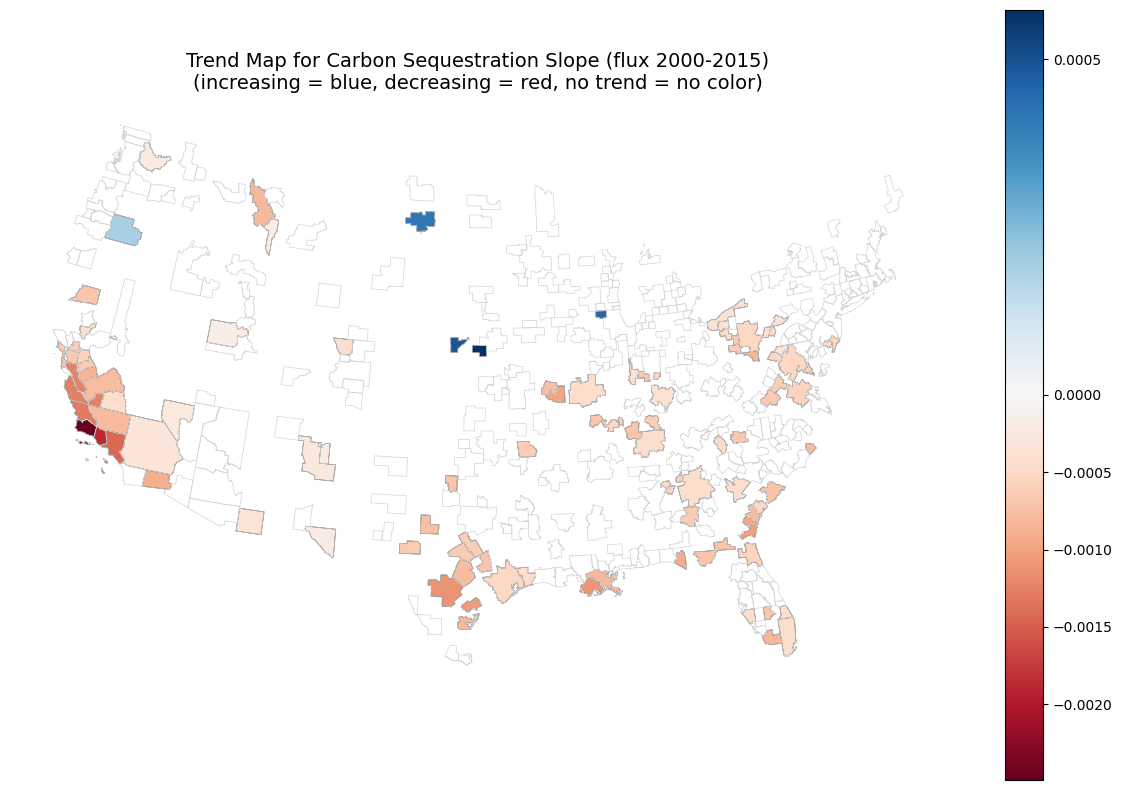

In [110]:
nee_df = pd.read_csv(constants.NEE_MSA_MONTHLY_MEAN)
nee_df = nee_df.rename(columns=lambda x: x.replace("nee_mean_", "") if "nee_mean_" in x else x)
cs_df = nee_df.copy()
cs_df.iloc[:, 1:] = cs_df.iloc[:, 1:] * -1 # convert to carbon sequestration by nee * -1
cs_trend = mk_trend_test(deseasonize_df(cs_df))
print_trend_brief_info(cs_trend, 'Carbon sequestration', show_msa=False)
plot_trend_map(msa_shp, cs_trend, title="Trend Map for Carbon Sequestration Slope (flux 2000-2015)")

#### Using new flux-xbase 2001-2021 nee product

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\1084722401.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing Carbon sequestration MSAs: 40
Number of decreasing Carbon sequestration MSAs: 61


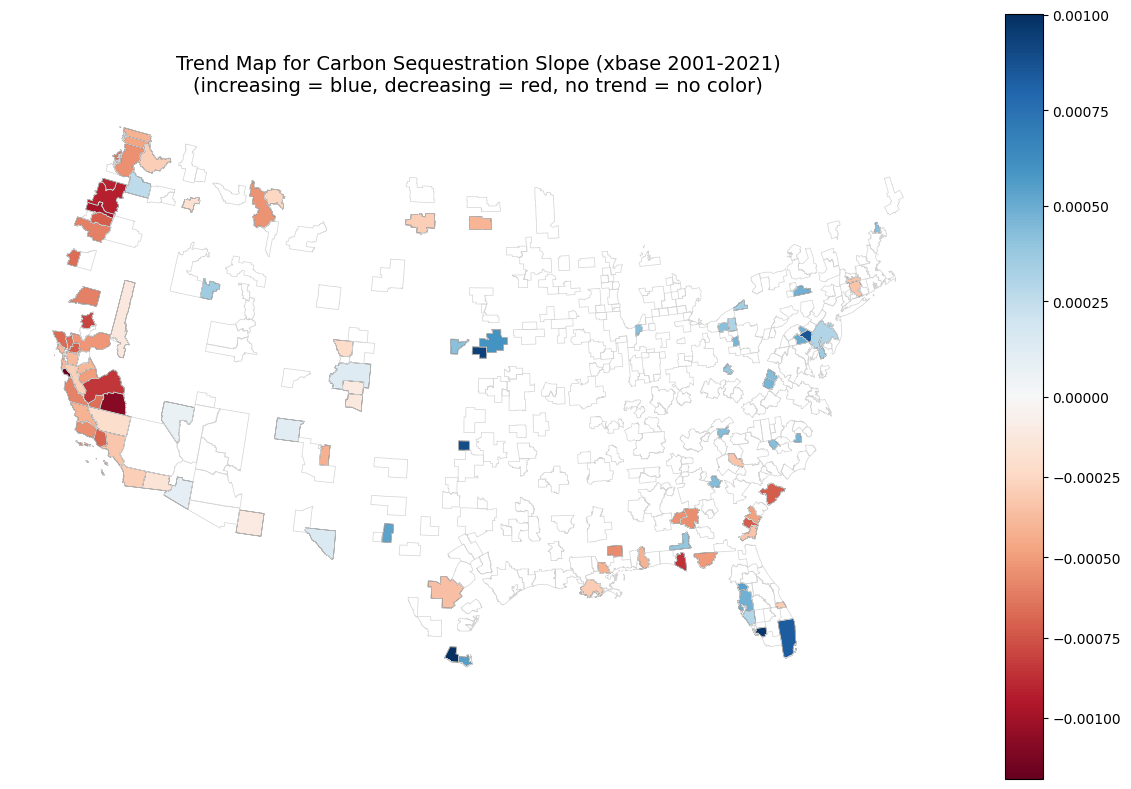

In [123]:
NEE_MSA_MONTHLY_MEAN_XBASE = r'c:\Users\qifanw\Documents\data\intermedia\msa_nee_mean_fluxx.csv'
nee_xbase_df = pd.read_csv(NEE_MSA_MONTHLY_MEAN_XBASE)
nee_xbase_df = nee_xbase_df.rename(columns=lambda x: x.replace("nee_mean_", "") if "nee_mean_" in x else x)
cs_xbase_df = nee_xbase_df.copy()
cs_xbase_df.iloc[:, 1:] = cs_xbase_df.iloc[:, 1:] * -1 # convert to carbon sequestration by nee * -1
cs_xbase_trend = mk_trend_test(deseasonize_df(cs_xbase_df))
print_trend_brief_info(cs_xbase_trend, 'Carbon sequestration', show_msa=False)
plot_trend_map(msa_shp, cs_xbase_trend, title="Trend Map for Carbon Sequestration Slope (xbase 2001-2021)")

slope: gC m-2 day-1 month-1
slope * 12: gC m-2 day-1
total yearly carbon sequestration change per area: slope * 12 * 365 gC m-2 year-1
total yearly carbon sequestration change: slope * 12 * 365 gC year-1 * msa_averge_area(m2)

In [133]:
# use xbase data for the final plot
cs_trend = cs_xbase_trend
cs_df = cs_xbase_df

In [125]:
cs_xbase_trend.to_csv(constants.CS_XBASE_TREND, index=False)

AttributeError: module 'constants' has no attribute 'CS_XBASE_TREND'

In [126]:
def plot_seasonal_change(df, info, show_mean=False):
    '''
    df (pd.DataFrame): DataFrame with time series data. and a single column of 'NAMELSAD'
    info (dict) {'title': (str), 'xlabel': (str), 'ylabel': (str)}
    '''
    
    title, xlabel, ylable = info['title'], info['xlabel'], info['ylabel']
    plt.figure(figsize=(12, 6))
    
    if show_mean:
        mean_values = df.iloc[:, 1:].mean(axis=0)
        plt.plot(df.columns[1:], mean_values, color='red', label='Mean of Carbon Sequestration', linewidth=2, zorder=3)
        for index, row in df.iterrows():
            plt.plot(row.index[1:], row.values[1:], color='grey', alpha=0.5)
    else:
        for index, row in df.iterrows():
            plt.plot(row.index[1:], row.values[1:], label=row['NAMELSAD'])
    
    plt.xlabel(xlabel)
    plt.xticks(ticks=np.arange(0, len(row.index[1:]), 12), labels=[year[:4] for year in row.index[1:][::12]])
    plt.ylabel(ylable)
    plt.title(title)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    plt.tight_layout()
    plt.show()

Number of increasing MSAs in northeast: 9


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\1084722401.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


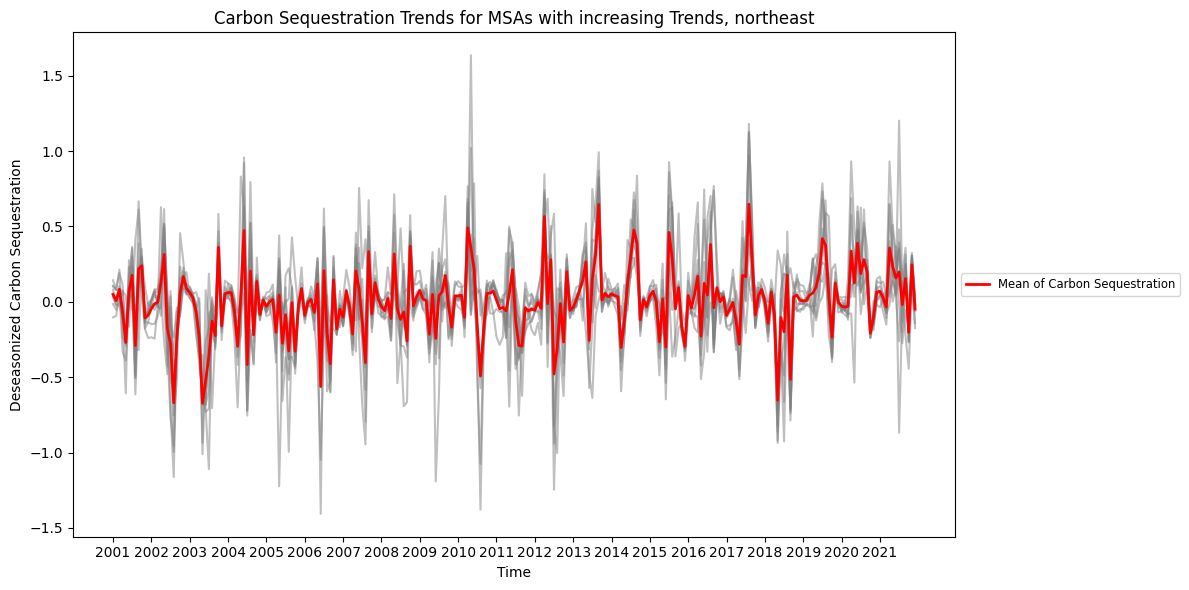

Number of increasing MSAs in ohio_valley: 6


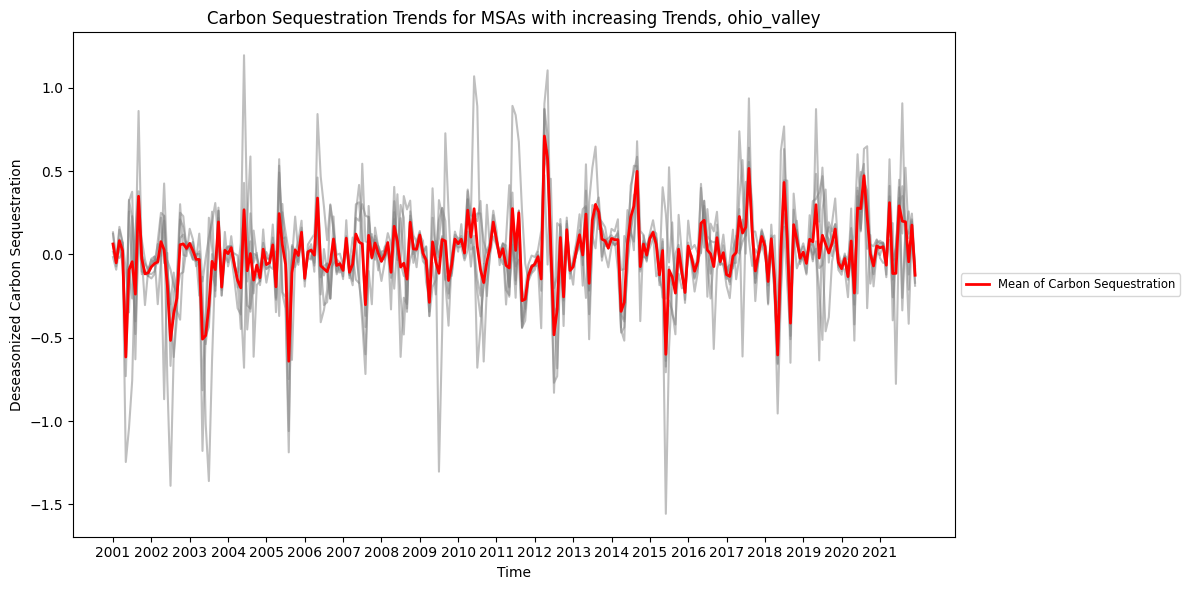

Number of increasing MSAs in southeast: 11


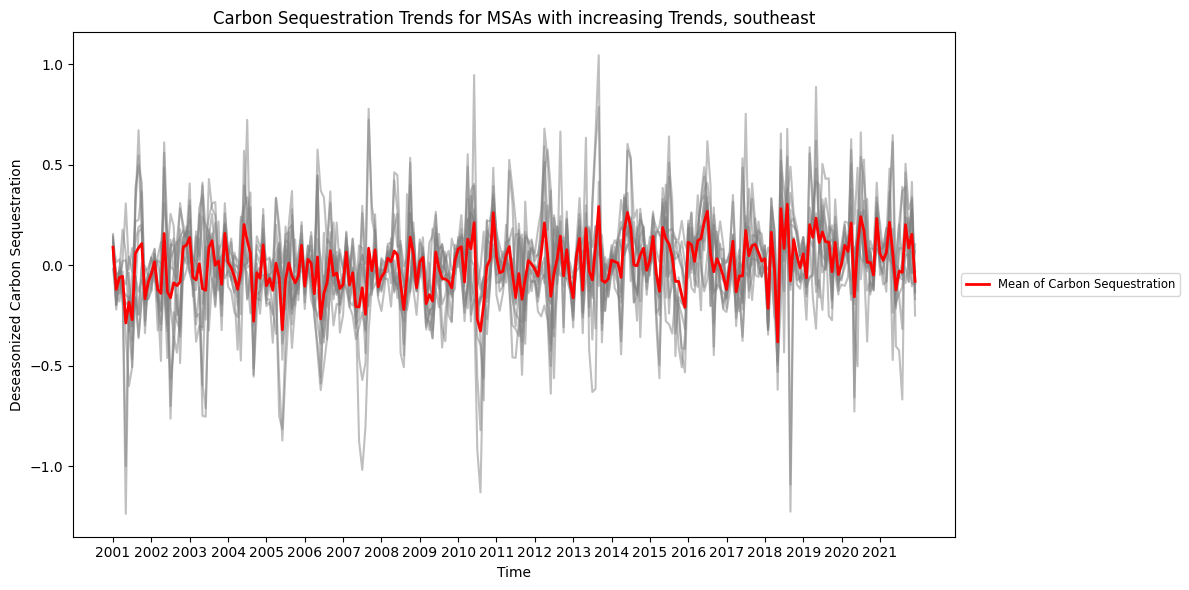

Number of increasing MSAs in northern_rockies_plains: 3


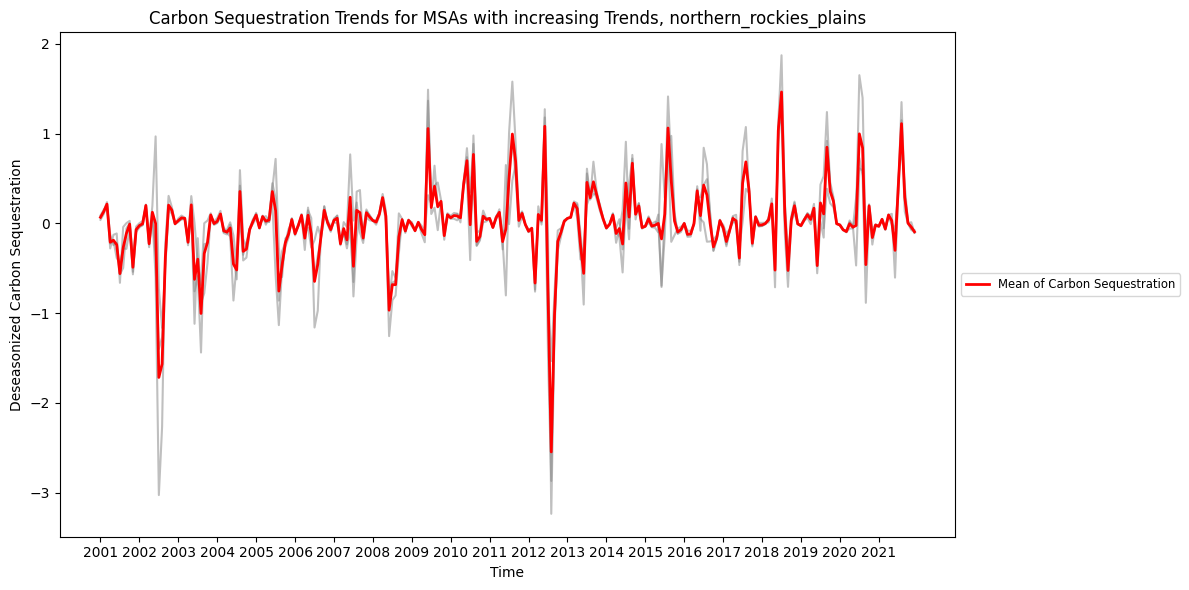

Number of increasing MSAs in south: 5


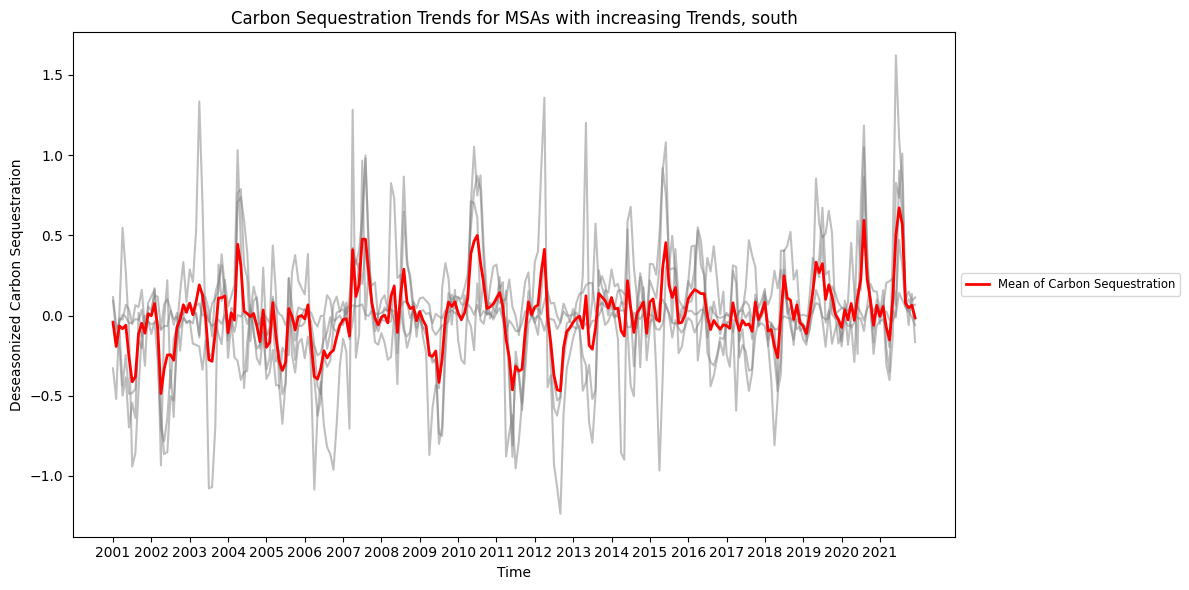

Number of increasing MSAs in southwest: 3


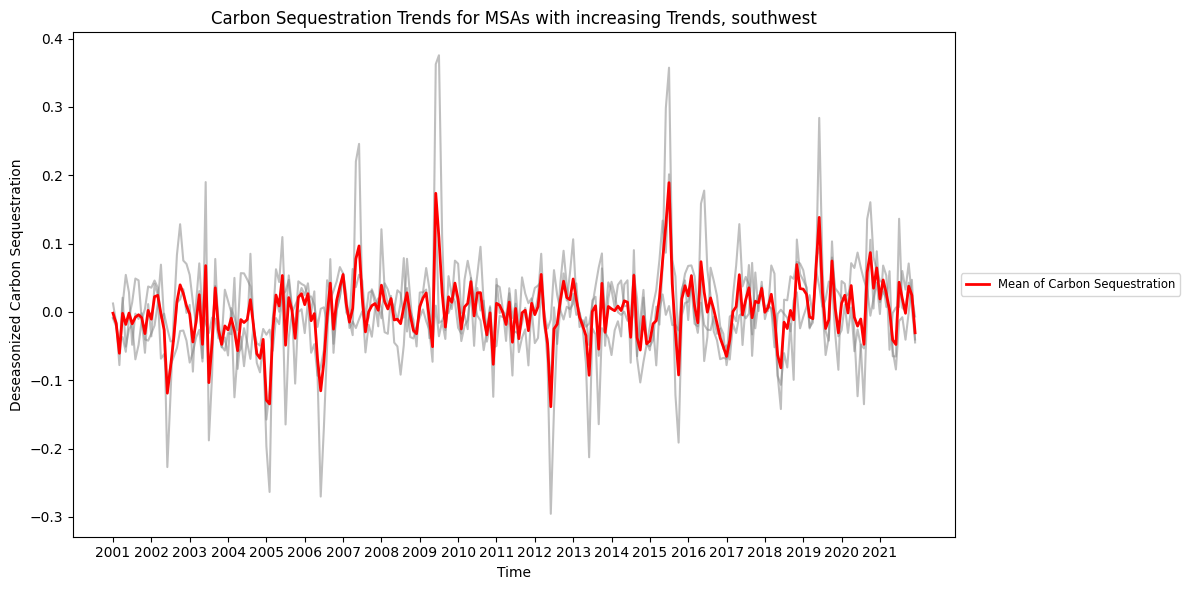

Number of increasing MSAs in northwest: 2


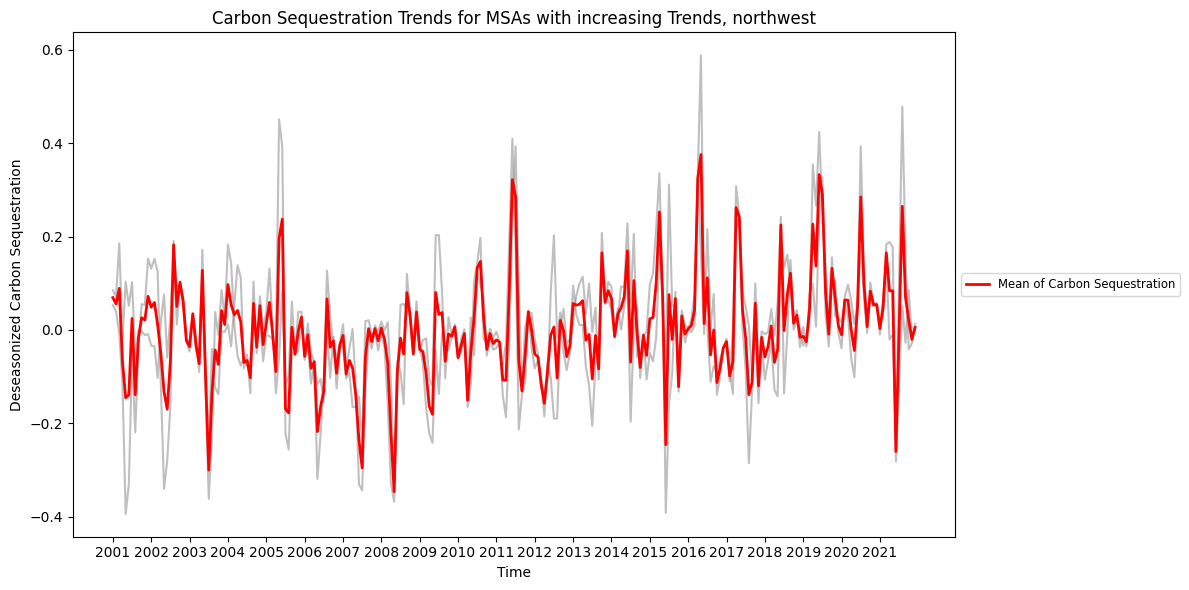

Number of increasing MSAs in west: 1


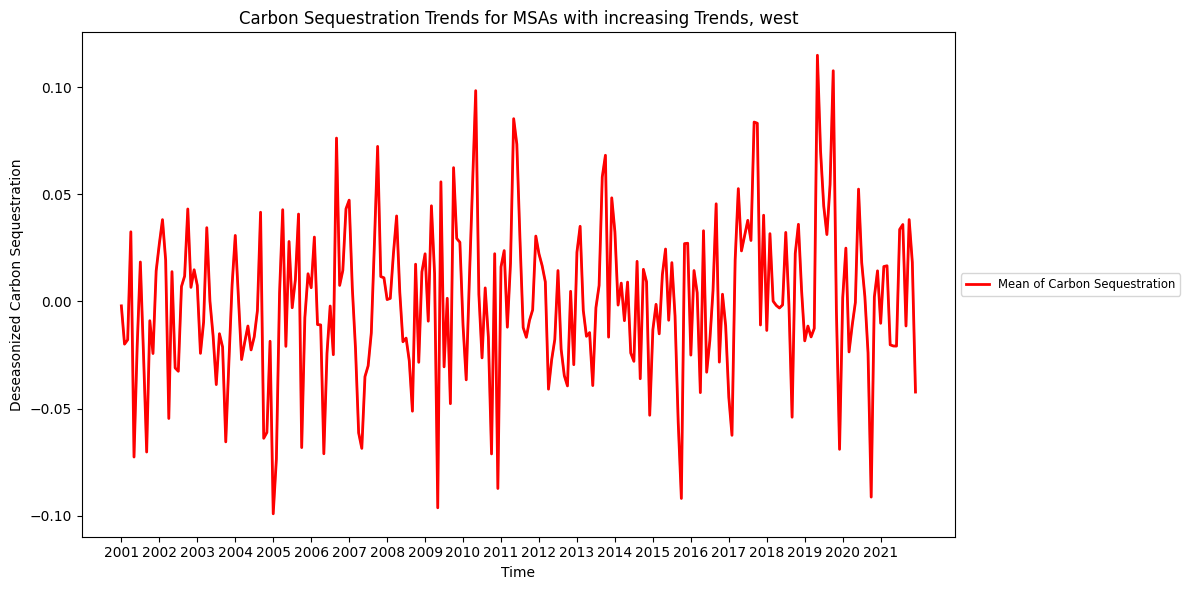

Number of decreasing MSAs in northeast: 2


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\1084722401.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


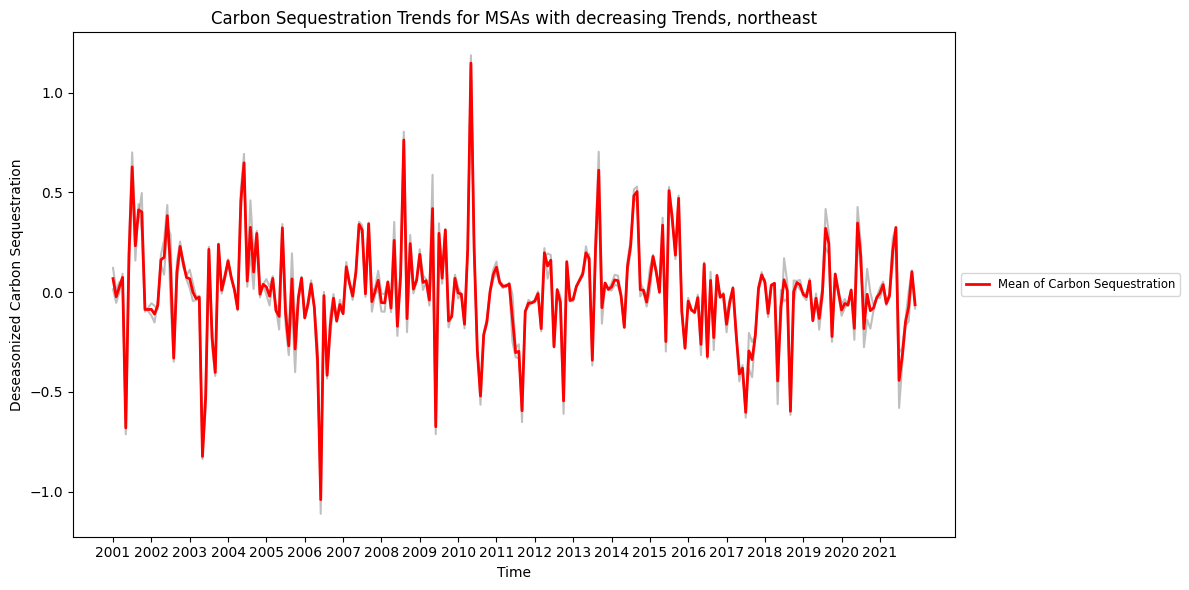

Number of decreasing MSAs in southeast: 11


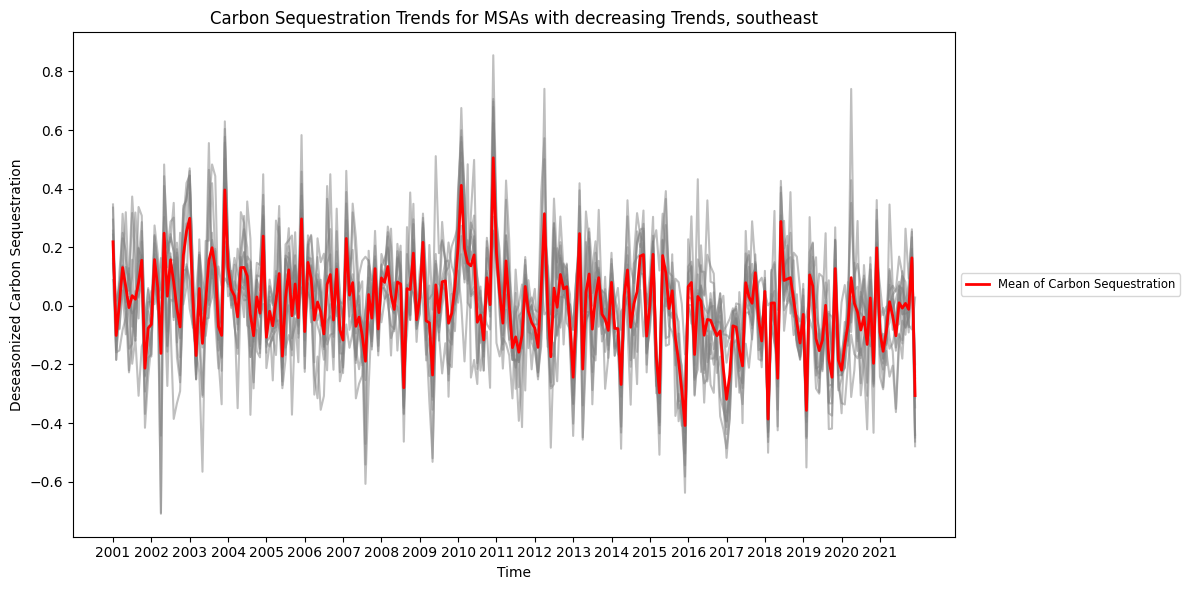

Number of decreasing MSAs in northern_rockies_plains: 4


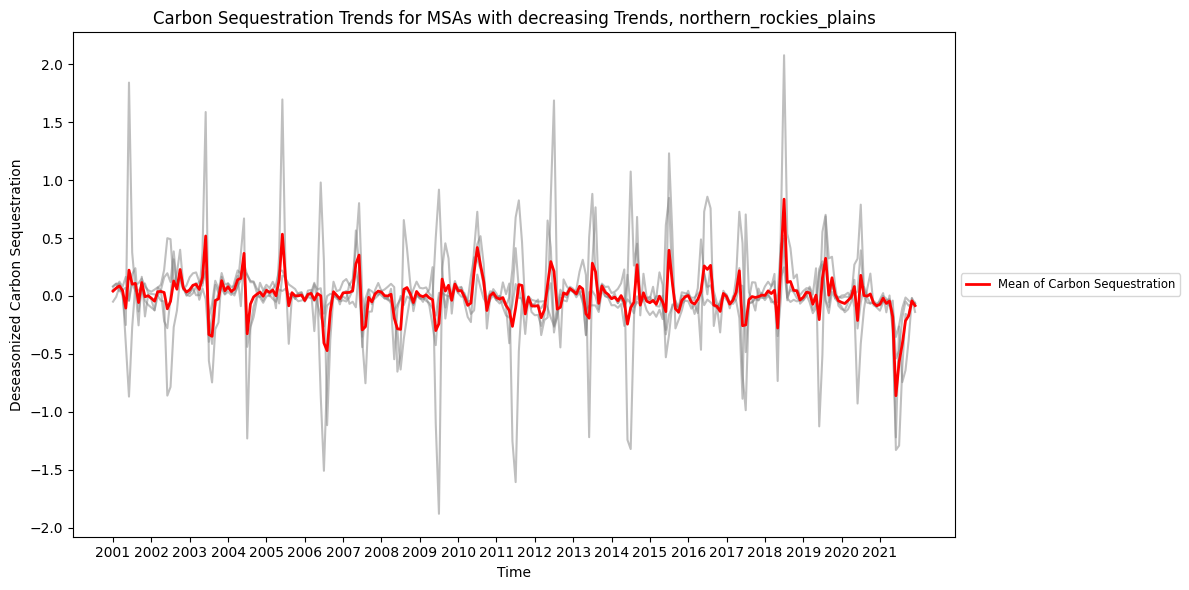

Number of decreasing MSAs in south: 4


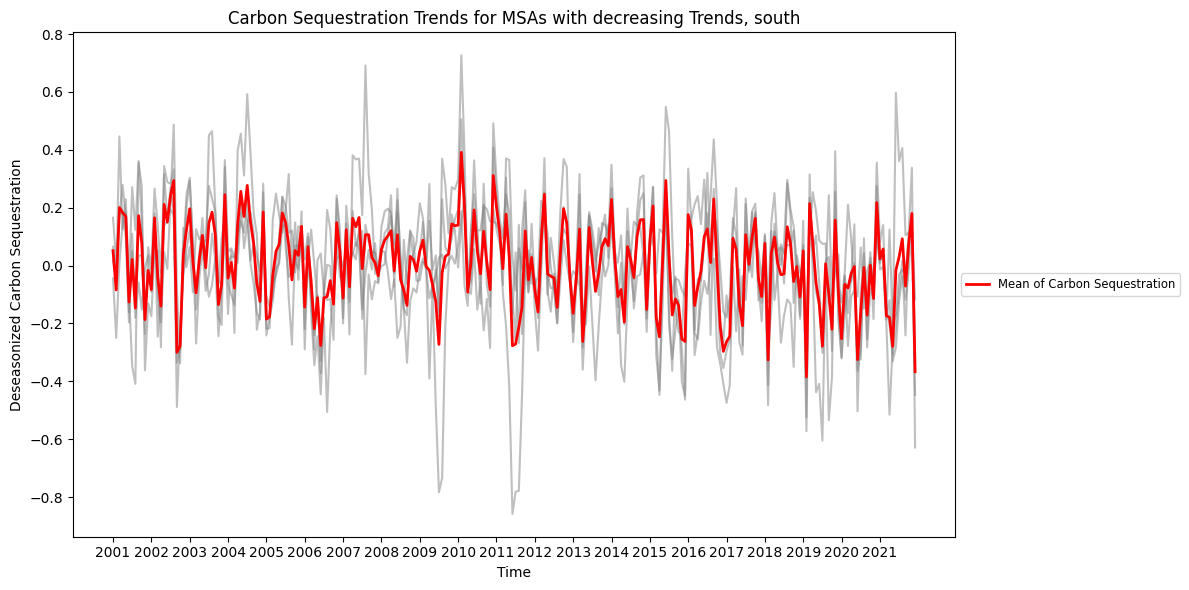

Number of decreasing MSAs in southwest: 5


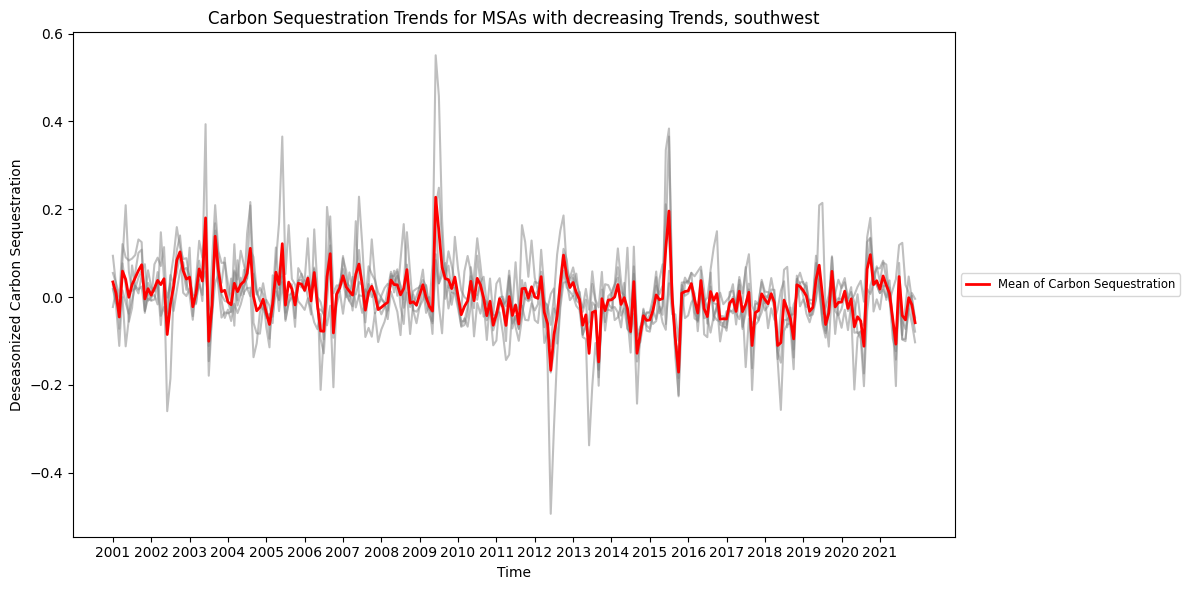

Number of decreasing MSAs in northwest: 12


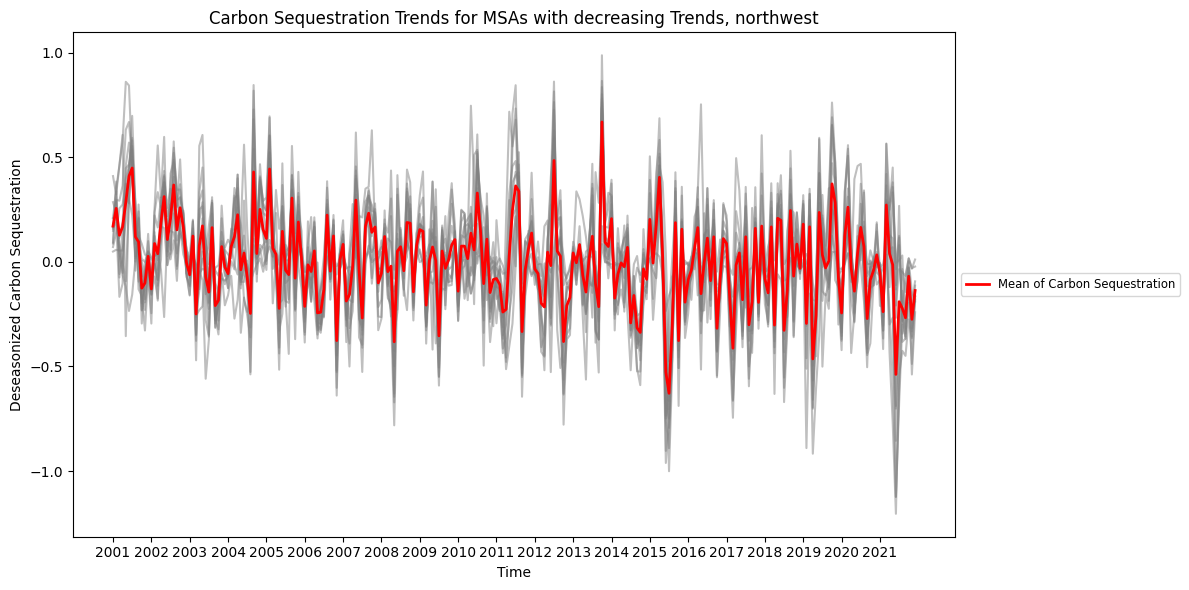

Number of decreasing MSAs in west: 23


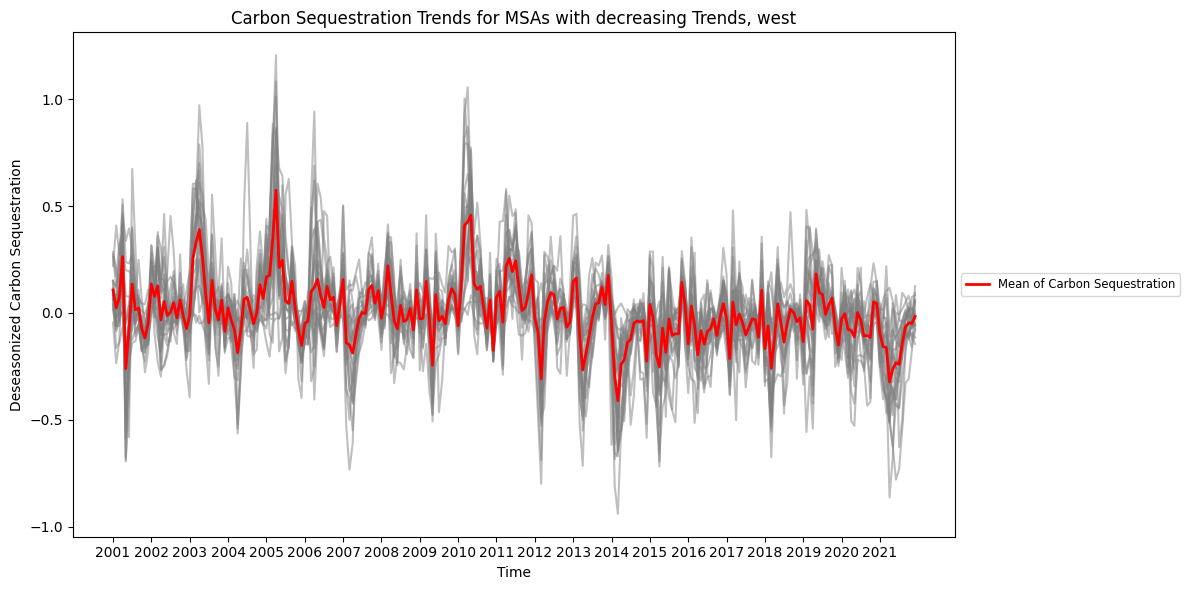

In [134]:
for trend in ['increasing', 'decreasing']:
    cs_df_ing = cs_trend[cs_trend['trend'] == trend][['NAMELSAD']].merge(deseasonize_df(cs_df), how='left')
    for region in constants.CLIMATE_ZONE.keys():
        region_msa = msa_region_name[msa_region_name['region'] == region][['NAMELSAD']]
        cs_df_region = region_msa.merge(cs_df_ing, on='NAMELSAD', how='inner')
        if len(cs_df_region) != 0:
            print(f"Number of {trend} MSAs in {region}: {len(cs_df_region)}")
            plot_seasonal_change(cs_df_region, 
                                {'title': f'Carbon Sequestration Trends for MSAs with {trend} Trends, {region}', 'xlabel': 'Time', 'ylabel': 'Deseasonized Carbon Sequestration'},
                                show_mean=True)

### PRISM Climate params trend

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing ppt MSAs: 13
No decreasing MSAs found for ppt.
Number of increasing tmean MSAs: 20
Number of decreasing tmean MSAs: 3
Number of increasing tdmean MSAs: 3
Number of decreasing tdmean MSAs: 168


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:57: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  decreasing.plot(ax=ax, color='green')


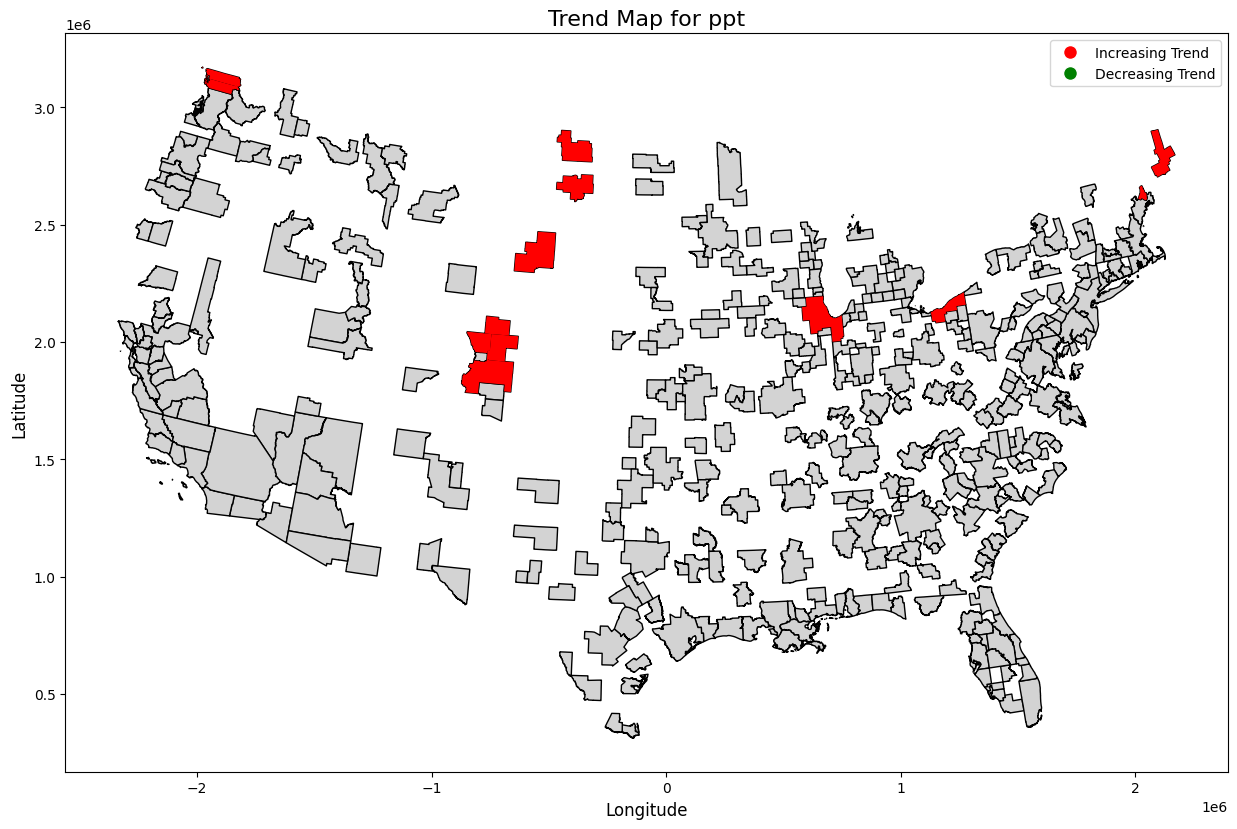

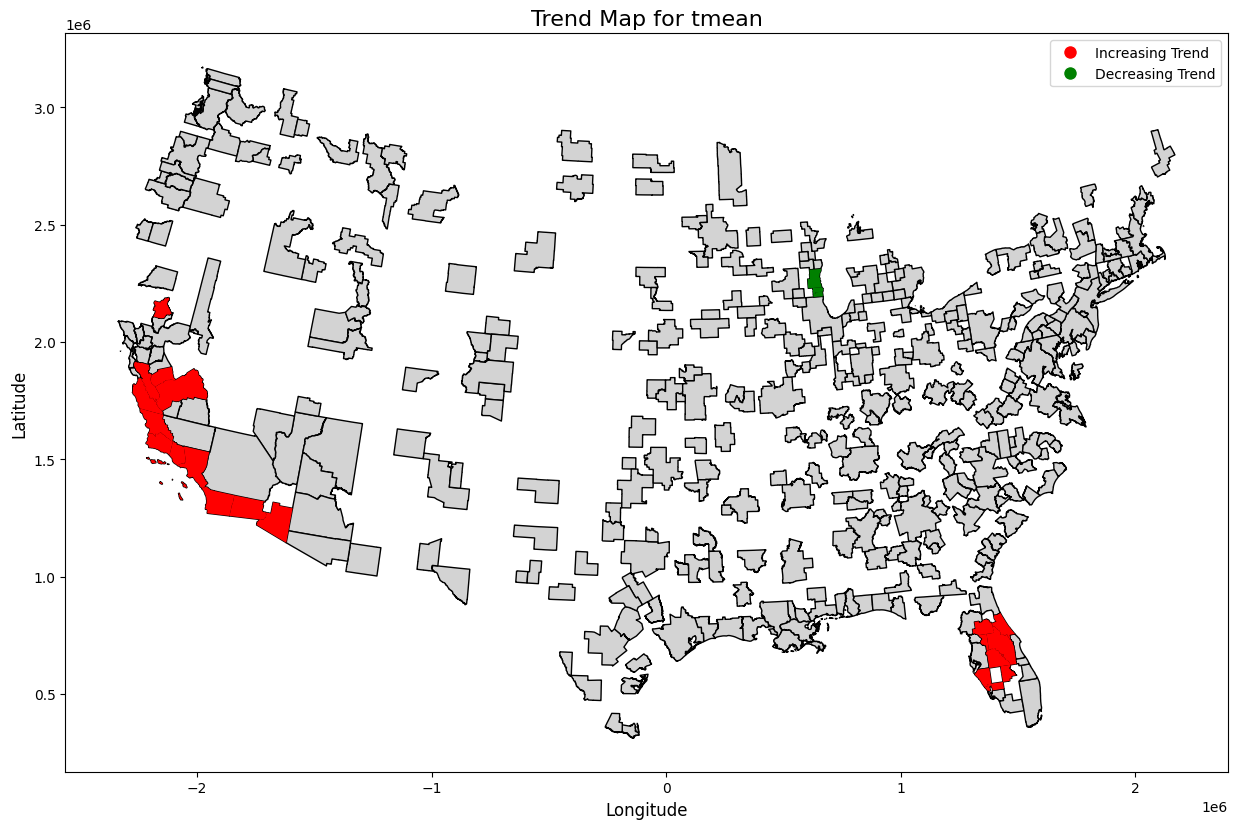

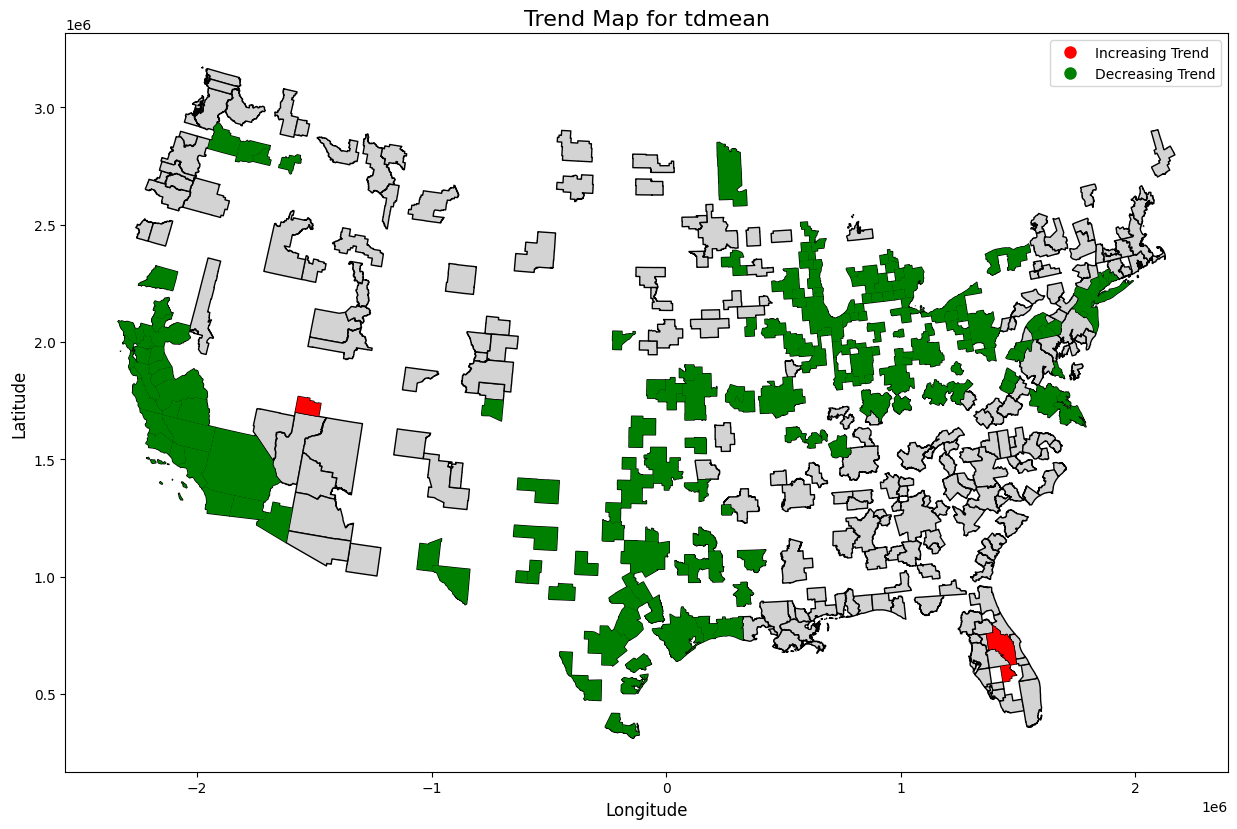

In [ ]:
ppt_df = pd.read_csv(constants.PPT_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tmean_df = pd.read_csv(constants.TMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tdmean_df = pd.read_csv(constants.TDMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})

ppt_trend = mk_trend_test(deseasonize_df(ppt_df))
tdmean_trend = mk_trend_test(deseasonize_df(tdmean_df))
tmean_trend = mk_trend_test(deseasonize_df(tmean_df))

for c_i, trend_df in {'ppt':ppt_trend, 'tmean':tmean_trend, 'tdmean':tdmean_trend}.items():
    print_trend_brief_info(trend_df, c_i, show_msa=False)

plot_trend_map(msa_shp, ppt_trend, 'ppt')
plot_trend_map(msa_shp, tmean_trend, 'tmean')
plot_trend_map(msa_shp, tdmean_trend, 'tdmean')

### SIF trend

In [ ]:
sif_df = pd.read_csv(constants.SIF_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
sif_trend = mk_trend_test(deseasonize_df(sif_df))
print_trend_brief_info(sif_trend, 'sif', show_msa=False)

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing sif MSAs: 54
Number of decreasing sif MSAs: 55


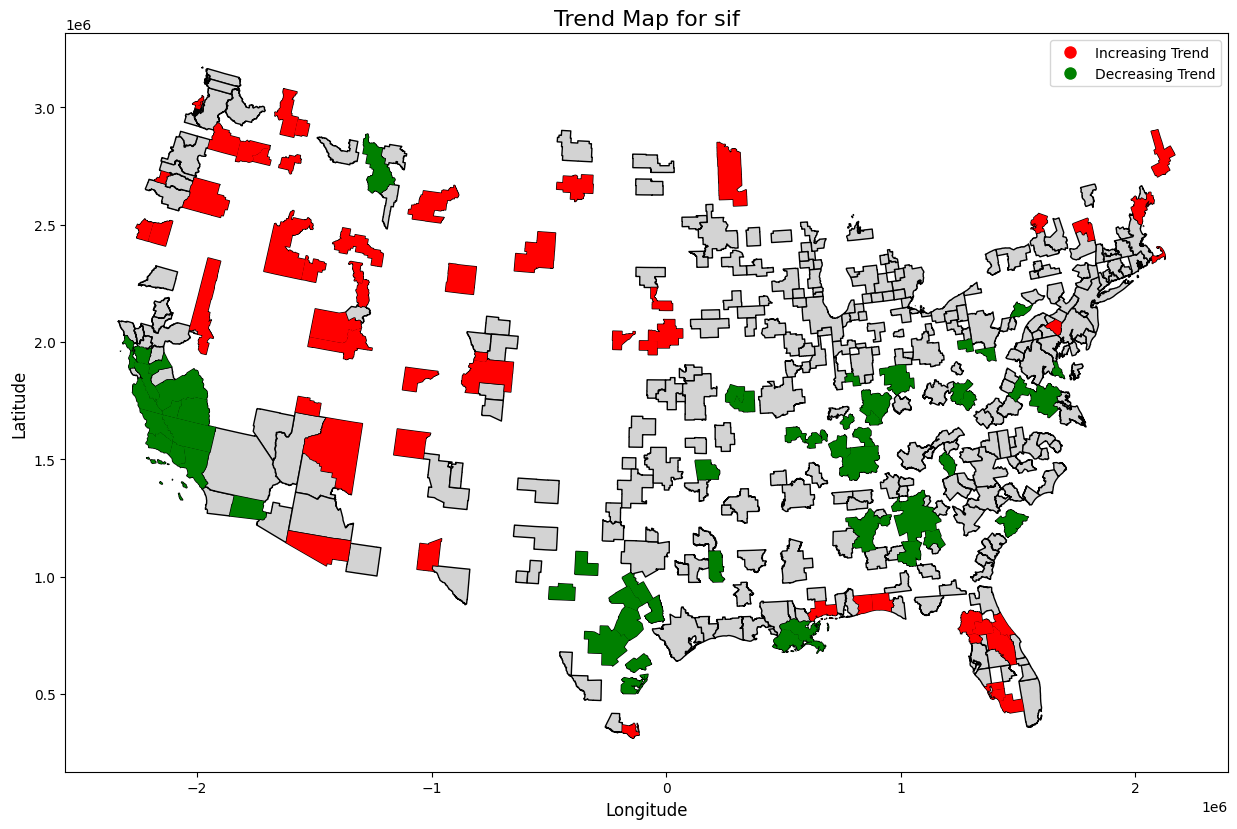

In [ ]:
plot_trend_map(msa_shp, sif_trend, 'sif')

granger casuality

In [74]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
data = sm.datasets.macrodata.load_pandas()
data = data.data[["realgdp", "realcons"]].pct_change().dropna()

In [75]:
data

,realgdp,realcons
1,0.025256,0.015404
2,-0.001192,0.010440
3,0.003501,0.001085
4,0.022438,0.009580
5,-0.004674,0.012652
...,...,...
198,-0.006758,-0.008908
199,-0.013710,-0.007812
200,-0.016475,0.001512
201,-0.001850,-0.002193


In [76]:
gc_res = grangercausalitytests(data, 4)
gc_res



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=28.7248 , p=0.0000  , df_denom=198, df_num=1
ssr based chi2 test:   chi2=29.1600 , p=0.0000  , df=1
likelihood ratio test: chi2=27.2295 , p=0.0000  , df=1
parameter F test:         F=28.7248 , p=0.0000  , df_denom=198, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=18.9880 , p=0.0000  , df_denom=195, df_num=2
ssr based chi2 test:   chi2=38.9498 , p=0.0000  , df=2
likelihood ratio test: chi2=35.5873 , p=0.0000  , df=2
parameter F test:         F=18.9880 , p=0.0000  , df_denom=195, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=13.5015 , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=41.9812 , p=0.0000  , df=3
likelihood ratio test: chi2=38.0914 , p=0.0000  , df=3
parameter F test:         F=13.5015 , p=0.0000  , df_denom=192, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=10.9646 , p=0.0000  